---
# FASTER R-CNN 2
---

# 0-) IMPORTS

In [10]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
from collections import defaultdict
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import xml.etree.ElementTree as ET
import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import seaborn as sns
import keras_cv

ModuleNotFoundError: No module named 'keras_cv'

In [3]:
gpus = tf.config.list_physical_devices('GPU')

tf.config.set_visible_devices(gpus[0], 'GPU')

from tensorflow.python.client import device_lib
print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')), "\n")

# Tüm cihazları listele ve her cihazın türünü yazdır
local_devices = device_lib.list_local_devices()

for device in local_devices:
    print(f"Device Name: {device.name}")
    print(f"Device Type: {device.device_type}")
    print(f"Device Description: {device.physical_device_desc}")
    print("-" * 40)

TensorFlow Version: 2.10.0
Num GPUs Available:  2 

Device Name: /device:CPU:0
Device Type: CPU
Device Description: 
----------------------------------------
Device Name: /device:GPU:0
Device Type: GPU
Device Description: device: 0, name: DML, pci bus id: <undefined>
----------------------------------------
Device Name: /device:GPU:1
Device Type: GPU
Device Description: device: 1, name: DML, pci bus id: <undefined>
----------------------------------------


In [4]:
# %% 1-) Data Preparation
def parse_annotation(annotation_path):
    tree = ET.parse(annotation_path)
    root = tree.getroot()
    
    objects = []
    for obj in root.findall('object'):
        obj_dict = {
            'class': obj.find('name').text,
            'xmin': int(obj.find('bndbox/xmin').text),
            'ymin': int(obj.find('bndbox/ymin').text),
            'xmax': int(obj.find('bndbox/xmax').text),
            'ymax': int(obj.find('bndbox/ymax').text)
        }
        objects.append(obj_dict)
        
    return {
        'filename': root.find('filename').text,
        'width': int(root.find('size/width').text),
        'height': int(root.find('size/height').text),
        'objects': objects
    }

# Load dataset
annotations_dir = Path("Dataset/annotations")
images_dir = Path("Dataset/images")

data = []
for xml_file in annotations_dir.glob("*.xml"):
    annotation = parse_annotation(xml_file)
    data.append({
        'image_path': str(images_dir / annotation['filename']),
        'objects': annotation['objects']
    })

# Split dataset
train_data, test_val_data = train_test_split(data, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(test_val_data, test_size=0.5, random_state=42)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

Training samples: 3500
Validation samples: 750
Test samples: 750


Training Samples:


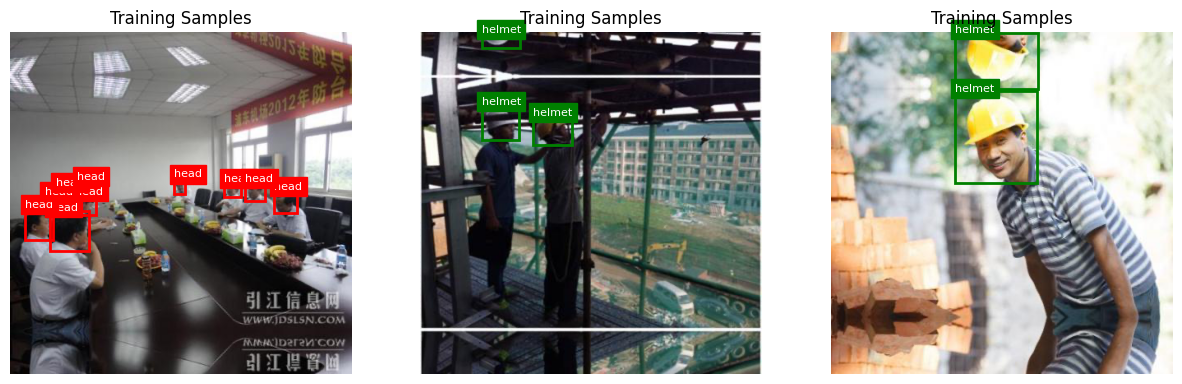


Validation Samples:


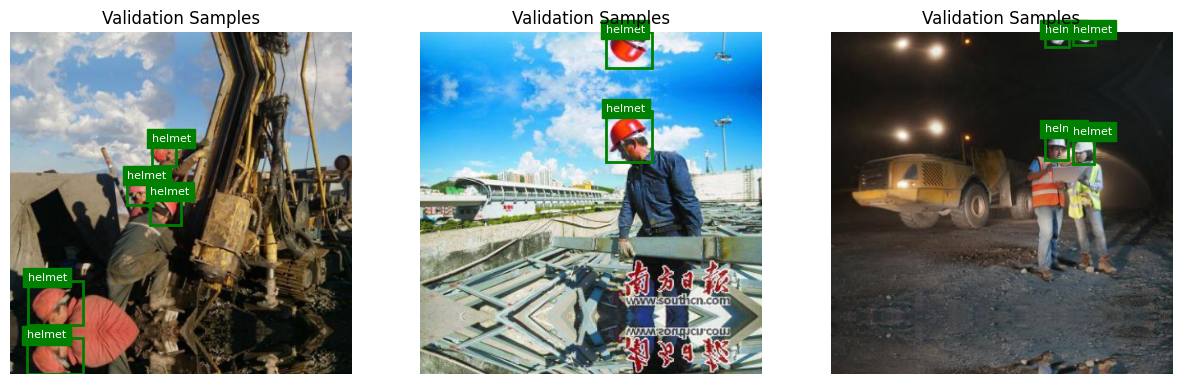


Test Samples:


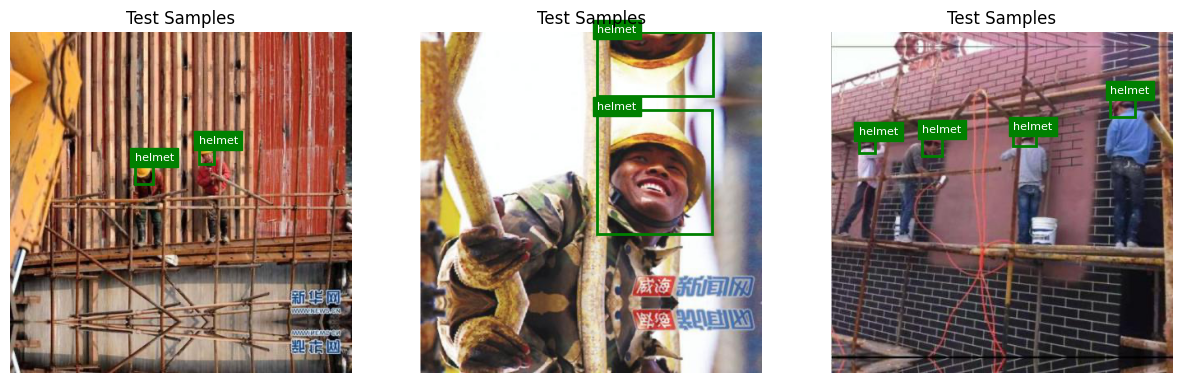

In [5]:
# %% 2-) Data Visualization
def visualize_dataset(samples, title):
    plt.figure(figsize=(15, 10))
    for i, sample in enumerate(samples[:3], 1):
        image = cv2.cvtColor(cv2.imread(sample['image_path']), cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 3, i)
        plt.imshow(image)
        ax = plt.gca()
        
        for obj in sample['objects']:
            color = 'green' if obj['class'] == 'helmet' else 'red'
            rect = plt.Rectangle(
                (obj['xmin'], obj['ymin']),
                obj['xmax'] - obj['xmin'],
                obj['ymax'] - obj['ymin'],
                fill=False,
                edgecolor=color,
                linewidth=2
            )
            ax.add_patch(rect)
            plt.text(
                obj['xmin'], obj['ymin'],
                obj['class'],
                color='white',
                backgroundcolor=color,
                fontsize=8
            )
        plt.axis('off')
        plt.title(title)
    plt.show()

print("Training Samples:")
visualize_dataset(train_data, "Training Samples")
print("\nValidation Samples:")
visualize_dataset(val_data, "Validation Samples")
print("\nTest Samples:")
visualize_dataset(test_data, "Test Samples")

In [8]:
# %% 3-) Modelling (VRAM Optimized)
from tqdm.auto import tqdm
import gc

# Analyze dataset with memory constraints
print("🛠️ Analyzing dataset...")
all_classes = set()
max_boxes = 0

# First pass: Find classes and max boxes
for sample in tqdm(data, desc="Scanning dataset"):
    max_boxes = max(max_boxes, len(sample['objects']))
    all_classes.update(obj['class'] for obj in sample['objects'])

print(f"\n🔍 Analysis results:\n- Classes: {all_classes}\n- Max boxes: {max_boxes}")

# Class mappings
class_ids = {cls: i+1 for i, cls in enumerate(sorted(all_classes))}  # 0 for background
class_names = {v: k for k, v in class_ids.items()}
print(f"\n📋 Class mappings: {class_ids}")

# Optimized dataset pipeline
def create_dataset(data, batch_size=2, shuffle=False, desc="Processing"):  # Reduced batch size
    def generator():
        for sample in data:
            # Load image
            img = tf.io.read_file(sample['image_path'])
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.convert_image_dtype(img, tf.float32)
            
            # Process boxes
            boxes = []
            labels = []
            for obj in sample['objects']:
                try:
                    boxes.append([obj['xmin'], obj['ymin'], obj['xmax'], obj['ymax']])
                    labels.append(class_ids[obj['class']])
                except KeyError:
                    continue
            
            if not boxes:
                continue
                
            # Pad dynamically per batch
            pad_amount = max_boxes - len(boxes)
            yield (
                img,
                tf.pad(boxes, [(0, pad_amount), (0, 0)]),
                tf.pad(labels, [(0, pad_amount)])
            )
    # Create dataset with memory optimization
    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(None, None, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(None, 4), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.int32)
        )
    )
    
    # Corrected pipeline chaining
    return (dataset
            .apply(tf.data.experimental.dense_to_ragged_batch(batch_size))
            .map(lambda imgs, boxes, labels: {
                'images': tf.image.resize(imgs, (512, 512)),
                'bounding_boxes': {
                    'boxes': boxes,
                    'classes': labels
                }
            }, num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE)
            .cache())

# Memory-friendly dataset creation
print("\n🚀 Creating datasets:")
train_ds = create_dataset(train_data, batch_size=2, desc="Training")
val_ds = create_dataset(val_data, batch_size=1, desc="Validation")
test_ds = create_dataset(test_data, batch_size=1, desc="Testing")

# Clear memory
del data, train_data, val_data, test_data
gc.collect()

# VRAM Optimization
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

# Mixed precision setup
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Optimized model
model = keras_cv.models.RetinaNet(
    num_classes=len(class_ids)+1,  # +1 for background
    bounding_box_format="xyxy",
    backbone=keras_cv.models.ResNet50Backbone.from_preset(
        "resnet50_imagenet",
        input_shape=(512, 512, 3)  # Match resized images
    ),
    label_encoder=keras_cv.layers.RetinaNetLabelEncoder(
        bounding_box_format="xyxy",
        box_variance=[0.1, 0.1, 0.2, 0.2]
    )
)

# Compile with memory optimizations
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-5),  # Lower learning rate
    classification_loss=keras_cv.losses.FocalLoss(
        from_logits=True,
        reduction="sum"  # More memory efficient
    ),
    box_loss=keras_cv.losses.SmoothL1Loss(
        l1_cutoff=1.0,
        reduction="sum"
    ),
    weighted_metrics=[]
)

# Training with memory monitoring
class VRAMCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        stats = tf.config.experimental.get_memory_info('GPU:0')
        print(f"\n💻 VRAM Usage: {stats['current'] / 1024**3:.2f}GB / {stats['peak'] / 1024**3:.2f}GB")

print("\n🔥 Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        VRAMCallback(),
        keras.callbacks.ModelCheckpoint(
            "best_model.keras",
            save_weights_only=True,  # Save space
            monitor='val_loss',
            save_best_only=True
        ),
        TqdmProgressCallback(total_epochs=10)
    ],
    verbose=0
)

# Cleanup
tf.keras.backend.clear_session()
gc.collect()

🛠️ Analyzing dataset...


Scanning dataset: 100%|██████████| 5000/5000 [00:00<00:00, 555581.11it/s]


🔍 Analysis results:
- Classes: {'head', 'person', 'helmet'}
- Max boxes: 68

📋 Class mappings: {'head': 1, 'helmet': 2, 'person': 3}

🚀 Creating datasets:


Physical devices cannot be modified after being initialized
Your GPUs may run slowly with dtype policy mixed_float16 because they do not have compute capability of at least 7.0. Your GPUs:
  DML, no compute capability (probably not an Nvidia GPU) (x2)
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


NameError: name 'keras_cv' is not defined